In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from ptlpinns.models import model, train_PDE, transfer_kpp
from ptlpinns.odes import numerical

/home/jovyan/PTL-PINNs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Problem setup

KPP-Fisher equation with polynomial nonlinearity:
$$u_t = D\,u_{xx} + \varepsilon\,(-u + u^2),
\quad u(x,0) = \sin^2\!\left(\frac{3\pi x}{L}\right),
\quad u(0,t)=u(L,t)=0,\quad D=0.01.$$

Epsilon sweep using the pretrained `KPP_Fisher_linear` backbone.
H is computed once; for each $\varepsilon$ the perturbation series is evaluated
up to $p_{\max}$ and the MAE at $p_{\max}$ is recorded against a
high-accuracy numerical (RK45) reference.

In [2]:
L, T = 2, 5
x_span, t_span = (0, L), (0, T)

Nx, Nt = 50, 50
x, t, grid = train_PDE.generate_interior_tensor(
    IG=(Nx, Nt), x_span=(0, L), t_span=(0, T), require_grad=False,
)

D      = 0.01
p_max  = 5
Polynomial = [[-1, 1], [1, 2]]   # encodes  P(u) = -u + u^2

epsilon_values = np.arange(0.05, 2.0, 0.10)

def ic_sin(inp):
    xv = inp[:, 0].unsqueeze(1)
    return (torch.sin(3 * torch.pi * xv / L)) ** 2

def constant_function(constant):
    def f(inp):
        return constant * torch.ones_like(inp[:, 0].unsqueeze(1))
    return f

ic          = ic_sin
bcs_torch   = [constant_function(0), constant_function(0)]
forcing_torch = constant_function(0)

def u_0_np(x_np):
    return (np.sin(3 * np.pi * x_np / L)) ** 2

### Load model and build $H$ (once)

In [3]:
name = "model_KPP_Fisher_linear.pth"
path = "/home/jovyan/PTL-PINNs/ptlpinns/models/train/KPP_Fisher_linear"

pinn = model.Multihead_model_PDE(k=9, bias=True)
pinn.load_state_dict(torch.load(f"{path}/{name}"))

bias = True
w_pde, w_bc, w_ic = 1, 10, 10
training_log = {
    "name": name, "bias": bias, "k": 9,
    "domain_info": {"L": L, "T": T},
    "Nx": Nx, "Nt": Nt,
    "w_pde": w_pde, "w_bc": w_bc, "w_ic": w_ic,
}

H_dict = transfer_kpp.compute_H_dict(
    model=pinn, IG=(Nx, Nt), Nic=Nx, Nbc=Nt, bias=bias,
    x_span=x_span, t_span=t_span, D=D, log=training_log,
)
_, _, _ = transfer_kpp.compute_M(H_dict=H_dict, w_pde=w_pde, w_ic=w_ic, w_bc=w_bc)

input_grid = torch.cat((x.unsqueeze(1), t.unsqueeze(1)), dim=1)

Differentiating H w.r.t. x now...
Finished computing H2x.
Differentiating H w.r.t. t now...
Finished computing Ht


### Epsilon sweep

In [4]:
sweep_maes = []

print(f"Running KPP-Fisher epsilon sweep  (D={D}, p_max={p_max}) ...")
for epsilon in epsilon_values:
    result_ref = numerical.solution_KPP(
        [epsilon], D,
        [lambda u: -u + u**2],
        x_span, t_span, Nx, Nt,
        [u_0_np],
        [lambda xv, tv: 0],
        [[lambda tv: 0, lambda tv: 0]],
    ).squeeze()

    cumulative, _ = transfer_kpp.compute_perturbation_solution_polynomial_orders(
        p_max, epsilon, forcing_torch,
        H_dict=H_dict, input=input_grid,
        training_log=training_log,
        Polynomial=Polynomial,
        boundary_functions=bcs_torch,
        ic_function=ic,
    )

    mae = float(np.mean(np.abs(cumulative[-1].reshape(Nx, Nt) - result_ref)))
    sweep_maes.append(mae)
    print(f"  ε={epsilon:.2f}  MAE@p={p_max}: {mae:.3e}")

print(f"done — {len(sweep_maes)} epsilon values")

Running KPP-Fisher epsilon sweep  (D=0.01, p_max=5) ...
  ε=0.05  MAE@p=5: 2.635e-03
  ε=0.15  MAE@p=5: 2.636e-03
  ε=0.25  MAE@p=5: 2.668e-03
  ε=0.35  MAE@p=5: 2.876e-03
  ε=0.45  MAE@p=5: 4.325e-03
  ε=0.55  MAE@p=5: 9.634e-03
  ε=0.65  MAE@p=5: 2.377e-02
  ε=0.75  MAE@p=5: 5.498e-02
  ε=0.85  MAE@p=5: 1.156e-01
  ε=0.95  MAE@p=5: 2.228e-01
  ε=1.05  MAE@p=5: 3.993e-01
  ε=1.15  MAE@p=5: 6.743e-01
  ε=1.25  MAE@p=5: 1.084e+00
  ε=1.35  MAE@p=5: 1.670e+00
  ε=1.45  MAE@p=5: 2.486e+00
  ε=1.55  MAE@p=5: 3.591e+00
  ε=1.65  MAE@p=5: 5.054e+00
  ε=1.75  MAE@p=5: 6.955e+00
  ε=1.85  MAE@p=5: 9.385e+00
  ε=1.95  MAE@p=5: 1.245e+01
done — 20 epsilon values


### MAE @ $p = p_{\max}$ vs $\varepsilon^{p_{\max}}$ — normalised comparison

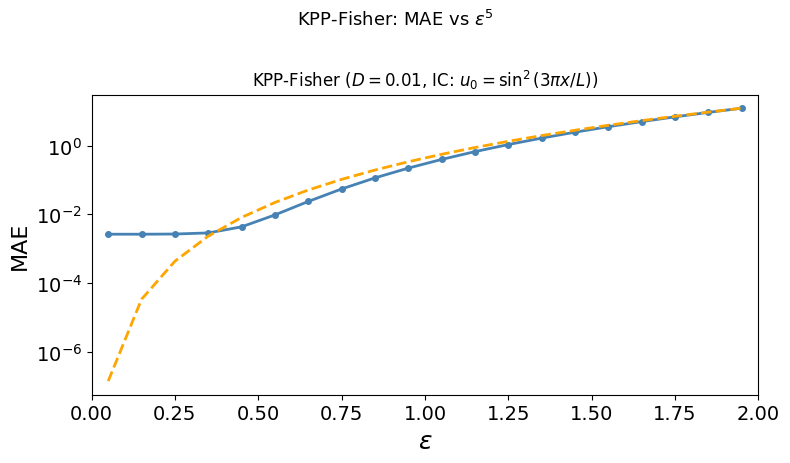

In [5]:
sweep_eps     = np.array(epsilon_values)
sweep_maes_arr = np.array(sweep_maes)
sweep_eps_ref = sweep_eps ** p_max

mae_norm = sweep_maes_arr
ref_norm = sweep_eps_ref  * np.max(sweep_maes_arr) / np.max(sweep_eps_ref)

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(sweep_eps, mae_norm, "o-", linewidth=2, markersize=4,
        color="steelblue", label=rf"MAE @ $p={p_max}$")
ax.plot(sweep_eps, ref_norm, "--", linewidth=2,
        color="orange", label=rf"$\varepsilon^{{{p_max}}}$")

ax.set_title(
    rf"KPP-Fisher ($D={D}$, IC: $u_0=\sin^2(3\pi x/L)$)",
    fontsize=12,
)
ax.set_yscale("log")
ax.set_xlim(0, 2.0)
ax.tick_params(axis="both", labelsize=14)
ax.set_xlabel(r"$\varepsilon$", fontsize=18)
ax.set_ylabel("MAE", fontsize=16)

fig.suptitle(
    rf"KPP-Fisher: MAE vs $\varepsilon^{{{p_max}}}$",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()